In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--dataset_id', 'kind-detuning-meas',
        '--file_dir', '../../data/kalman',
        '--file_name', 'tesla_meas',
        '--data_nsample', '144',
        '--feature_ndim', '3',
        '--target_ndim', '1',

        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
    ]
)


In [3]:
model = kind.model(args)
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model.train()
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=1.775919, valid=0.491901, test=0.496891
	validation loss decreased (inf -> 0.491901), saving model ...
	epoch 2 losses: train=1.475882, valid=0.290066, test=0.293936
	validation loss decreased (0.491901 -> 0.290066), saving model ...
	epoch 3 losses: train=0.894903, valid=0.250482, test=0.254858
	validation loss decreased (0.290066 -> 0.250482), saving model ...
	epoch 4 losses: train=0.864972, valid=0.247877, test=0.252077
	validation loss decreased (0.250482 -> 0.247877), saving model ...
	epoch 5 losses: train=0.859539, valid=0.248540, test=0.251152
	early stopping counter: 1 out of 30
	epoch 6 losses: train=0.850461, valid=0.239516, test=0.242881
	validation loss decreased (0.247877 -> 0.239516), saving model ...
	epoch 7 losses: train=0.744269, valid=0.214109, test=0.214777
	validation loss decreased (0.239516 -> 0.214109), saving model ...
	epoch 8 losses: train=0.695203, valid=0.200494, test=0.203563
	validation loss decreased

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

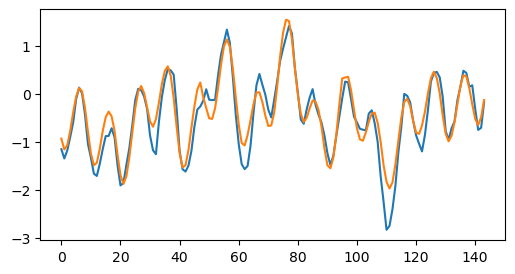

In [6]:
jdata = 9

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [7]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.570085, valid=0.465595, test=0.450079
	validation loss decreased (inf -> 0.465595), saving model ...
	epoch 2 losses: train=0.438815, valid=0.445418, test=0.430790
	validation loss decreased (0.465595 -> 0.445418), saving model ...
	epoch 3 losses: train=0.425303, valid=0.435007, test=0.420158
	validation loss decreased (0.445418 -> 0.435007), saving model ...
	epoch 4 losses: train=0.409901, valid=0.405276, test=0.389969
	validation loss decreased (0.435007 -> 0.405276), saving model ...
	epoch 5 losses: train=0.375438, valid=0.377140, test=0.358748
	validation loss decreased (0.405276 -> 0.377140), saving model ...
	epoch 6 losses: train=0.357450, valid=0.374172, test=0.353063
	validation loss decreased (0.377140 -> 0.374172), saving model ...
	epoch 7 losses: train=0.353942, valid=0.372993, test=0.353095
	validation loss decreased (0.374172 -> 0.372993), saving model ...
	epoch 8 losses: train=0.351255, valid=0.379618, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

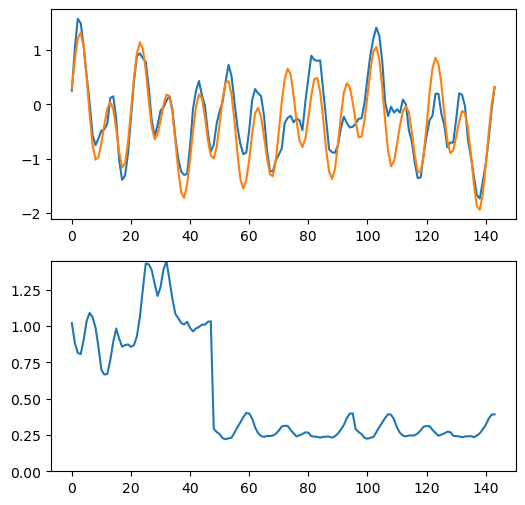

In [9]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break

In [10]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient mean >>>
	epoch 1 losses: train=1.882741, valid=1.719145, test=1.681188
	validation loss decreased (inf -> 1.719145), saving model ...
	epoch 2 losses: train=1.876878, valid=1.711806, test=1.674157
	validation loss decreased (1.719145 -> 1.711806), saving model ...
	epoch 3 losses: train=1.656560, valid=1.236768, test=1.233621
	validation loss decreased (1.711806 -> 1.236768), saving model ...
	epoch 4 losses: train=1.275592, valid=1.090603, test=1.090750
	validation loss decreased (1.236768 -> 1.090603), saving model ...
	epoch 5 losses: train=1.211683, valid=1.077957, test=1.077735
	validation loss decreased (1.090603 -> 1.077957), saving model ...
	epoch 6 losses: train=1.196063, valid=1.057649, test=1.056880
	validation loss decreased (1.077957 -> 1.057649), saving model ...
	epoch 7 losses: train=0.992121, valid=0.758096, test=0.766142
	validation loss decreased (1.057649 -> 0.758096), saving model ...
	epoch 8 losses: train=0.824490, valid=0.686283, test=0.697

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='trans')

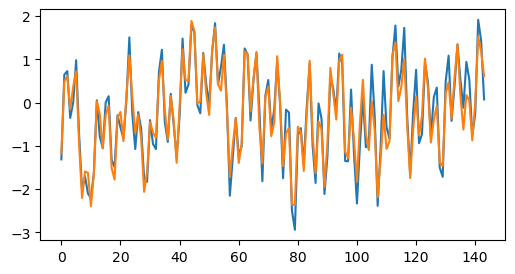

In [12]:
jdata = 21

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        trans = model_output[3]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.show()

        break

In [13]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train transient uncertainty >>>
	epoch 1 losses: train=0.295437, valid=0.083806, test=0.099932
	validation loss decreased (inf -> 0.083806), saving model ...
	epoch 2 losses: train=0.003960, valid=-0.063180, test=-0.052701
	validation loss decreased (0.083806 -> -0.063180), saving model ...
	epoch 3 losses: train=-0.109262, valid=-0.137549, test=-0.124552
	validation loss decreased (-0.063180 -> -0.137549), saving model ...
	epoch 4 losses: train=-0.168781, valid=-0.161484, test=-0.148982
	validation loss decreased (-0.137549 -> -0.161484), saving model ...
	epoch 5 losses: train=-0.221612, valid=-0.243913, test=-0.238119
	validation loss decreased (-0.161484 -> -0.243913), saving model ...
	epoch 6 losses: train=-0.261887, valid=-0.281029, test=-0.280253
	validation loss decreased (-0.243913 -> -0.281029), saving model ...
	epoch 7 losses: train=-0.259917, valid=-0.182382, test=-0.172089
	early stopping counter: 1 out of 30
	epoch 8 losses: train=-0.283333, valid=-0.314294, test=-

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

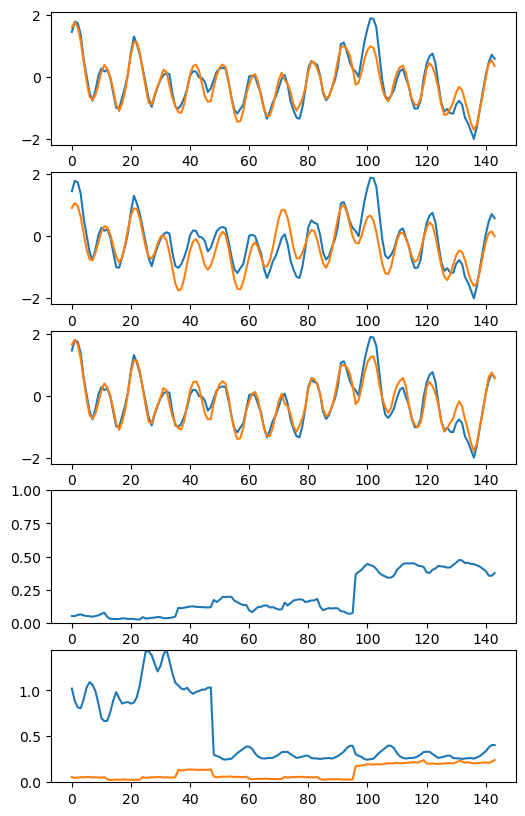

In [15]:
jdata = 30

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(dataset, back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        break